<a href="https://colab.research.google.com/github/camilorendonc45/curso-ia-para-economia/blob/main/Tercer_Parcial_Rendon_Mendoza_Cubillos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía
# 🏆 **Tercer parcial: Selección del Mejor Modelo**

---

**ESTÁ PROHIBIDO EL USO DE GRANDES MODELOS DE LENGUAJE COMO CHATGPT, CLAUDE, GEMINI, ENTRE OTROS, PARA RESOLVER ESTE EJERCICIO**

**Trabajo en grupos de 3**

**Objetivo:** Predecir las ventas de una compañía (`Sales`) teniendo en cuenta su inversión en publicidad.

**Dataset:** `train_df_ventas.csv` disponible en el repositorio del curso.

**IMPORTANTE: Los datos cargados solo corresponden a `train`.**

**Metodología:**
1.  Cargar y explorar los datos.
2.  Preprocesar los datos si es necesario.
3.  De los siguientes modelos, entrenar por lo menos 2:
    - Regresión Lineal
    - Regresión Polinómica
    - KNN Regressor
    - Decision Tree Regressor
    - Random Forest Regressor
    - Gradient Boosting Regressor
    - XGBoost Regressor
4.  Si lo considera necesario, usar `GridSearchCV` con Validación Cruzada (`cv=5`) para optimizar los hiperparámetros. La métrica de optimización debe ser el **RMSE** (Root Mean Squared Error), por lo que debe usar `scoring='neg_root_mean_squared_error'` (el valor será negativo y se multiplicará por -1 al final).
5.  Comparar los modelos y seleccionar el mejor, teniendo en cuenta el menor RMSE.

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Tercer_Parcial_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/Bsy2U83tbc. No olvide indicar claramente cuál es el modelo seleccionado.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Calificación**

La docente, evaluará el modelo seleccionado por ustedes en el `test set`.

El proceso seguirá estas reglas:

- **Criterio de Ganador:** El equipo que tenga todo el procedimiento correcto y obtenga el Root Mean Squared Error (RMSE) más bajo en el test set recibirá una calificación de 5.0.

- **Criterio de Desempate:** En caso de empate en el RMSE, se otorgará la ventaja al equipo que haya entrenado y evaluado más modelos.

- **Escalafón de Notas:** A partir del primer puesto, se restará 0.1 a la nota final por cada posición inferior (2º lugar: 4.9, 3er lugar: 4.8, etc.).

- **Validación de Procedimiento:** Es obligatorio que el código sea reproducible por la docente (no olivde colocar las semillas en los procesos aleatorios). Si el script contiene errores, el equipo quedará fuera de la competencia y se dará una calificación acorde a lo que esté correcto.

**Explicación de las variables:**

- Sales: Ventas (millones USD). --> **Esta es la variable objetivo**
- TV: Gasto en promoción televisiva (millones USD).
- Radio: Gasto en promoción radiofónica (millones USD).
- Social Media: Gasto en promoción en redes sociales (millones USD).
- Influencer: Indica si la promoción se realizó en colaboración con Mega, Macro, Nano o Micro influencers.


**Nombres estudiantes del equipo:**

- Camilo rendon c.
- Dana Mendoza
-Nicolas Cubillos

# **Desarrollo**

## 1. Importación de Librerías y Carga de Datos

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de Regresión
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


### Configuración de visualización

In [2]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.4f}'.format

# Configuraciones para una mejor visualización
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


### Carga de datos

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
path = '/content/drive/MyDrive/Bases'


In [5]:
# Para establecer el directorio de los archivos
os.chdir(path)


In [6]:
df = pd.read_csv('/content/drive/MyDrive/Bases/train_df_ventas.csv')
df.head(10)


,TV,Social Media,Influencer,Radio,Sales
0,17.5799,1.2190,Macro,22.2822,173.6121
1,14.5885,5.4783,Micro,22.0975,140.5407
2,25.1837,2.2799,Mega,22.1977,197.3528
3,12.8983,1.8315,Nano,21.7413,184.0478
4,28.3805,4.3385,Nano,22.6072,318.6275
5,6.2442,0.7593,Macro,21.3973,42.1961
6,17.7391,7.0695,Mega,22.6786,229.3026
7,10.4005,2.6070,Nano,21.6648,89.8401
8,19.2837,0.4818,Nano,22.8895,224.1130
9,5.9070,3.5880,Mega,21.9228,140.0247


## 2. Análisis Exploratorio de Datos (EDA)

Antes de modelar, es fundamental entender los datos: su estructura, distribuciones, valores faltantes y relaciones entre variables.


### 2.1. Información general del dataset

In [7]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nNúmero de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")


Dimensiones del dataset: (3636, 5)

Número de filas: 3636
Número de columnas: 5


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            3636 non-null   float64
 1   Social Media  3636 non-null   float64
 2   Influencer    3636 non-null   object 
 3   Radio         3636 non-null   float64
 4   Sales         3636 non-null   float64
dtypes: float64(4), object(1)
memory usage: 142.2+ KB


In [9]:
df.describe()


,TV,Social Media,Radio,Sales
count,"3,636.0000","3,636.0000","3,636.0000","3,636.0000"
mean,18.1659,3.3111,22.0850,192.4078
std,9.6715,2.2215,0.4757,92.5535
min,0.0007,0.0010,21.0351,31.1994
25%,10.5985,1.4836,21.7022,113.1740
50%,17.8896,3.0414,22.0455,189.5317
75%,25.6033,4.8040,22.4481,271.0513
max,48.8712,13.0840,23.2242,364.0798


### 2.2. Verificación de valores faltantes y duplicados

In [10]:
# Valores faltantes
print("=== Valores Faltantes por Columna ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Valores Faltantes': missing, 'Porcentaje (%)': missing_pct})
print(missing_df)

# Duplicados
print(f"\nNúmero de filas duplicadas: {df.duplicated().sum()}")


=== Valores Faltantes por Columna ===
              Valores Faltantes  Porcentaje (%)
TV                            0          0.0000
Social Media                  0          0.0000
Influencer                    0          0.0000
Radio                         0          0.0000
Sales                         0          0.0000

Número de filas duplicadas: 0


### 2.3. Distribución de la variable objetivo: `Sales`

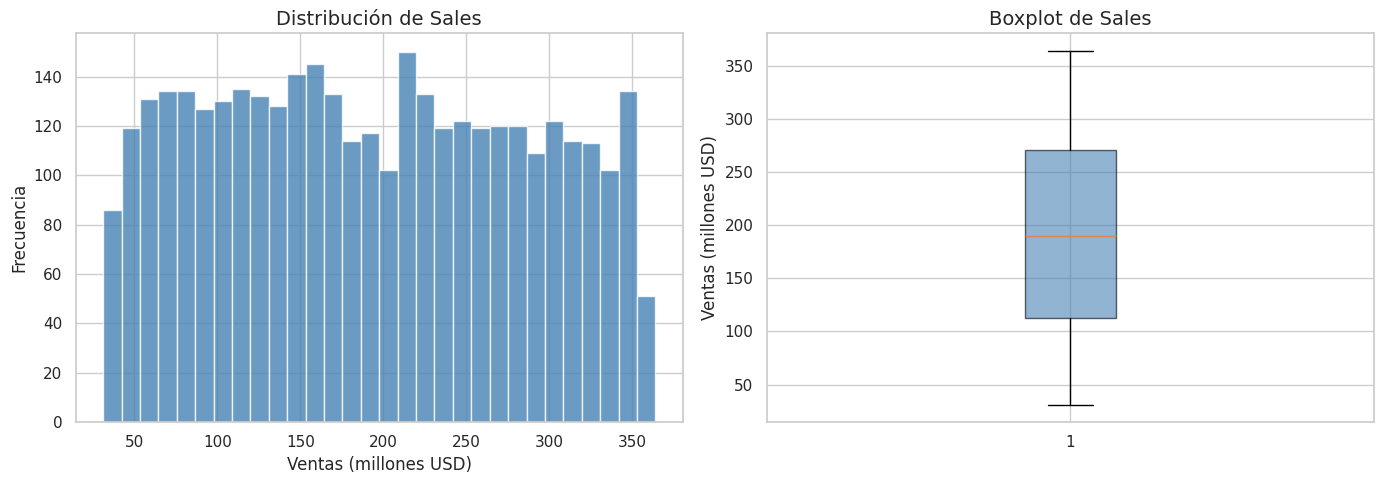


Estadísticas de Sales:
count   3,636.0000
mean      192.4078
std        92.5535
min        31.1994
25%       113.1740
50%       189.5317
75%       271.0513
max       364.0798
Name: Sales, dtype: float64
Skewness: 0.0689


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['Sales'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de Sales', fontsize=14)
axes[0].set_xlabel('Ventas (millones USD)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['Sales'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de Sales', fontsize=14)
axes[1].set_ylabel('Ventas (millones USD)')

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de Sales:")
print(df['Sales'].describe())
print(f"Skewness: {df['Sales'].skew():.4f}")


### 2.4. Distribución de variables numéricas

### 2.5. Variable categórica: `Influencer`

Distribución de la variable Influencer:
Influencer
Mega     925
Micro    920
Macro    905
Nano     886
Name: count, dtype: int64

Porcentajes:
Influencer
Mega     25.44%
Micro     25.3%
Macro    24.89%
Nano     24.37%
Name: proportion, dtype: object


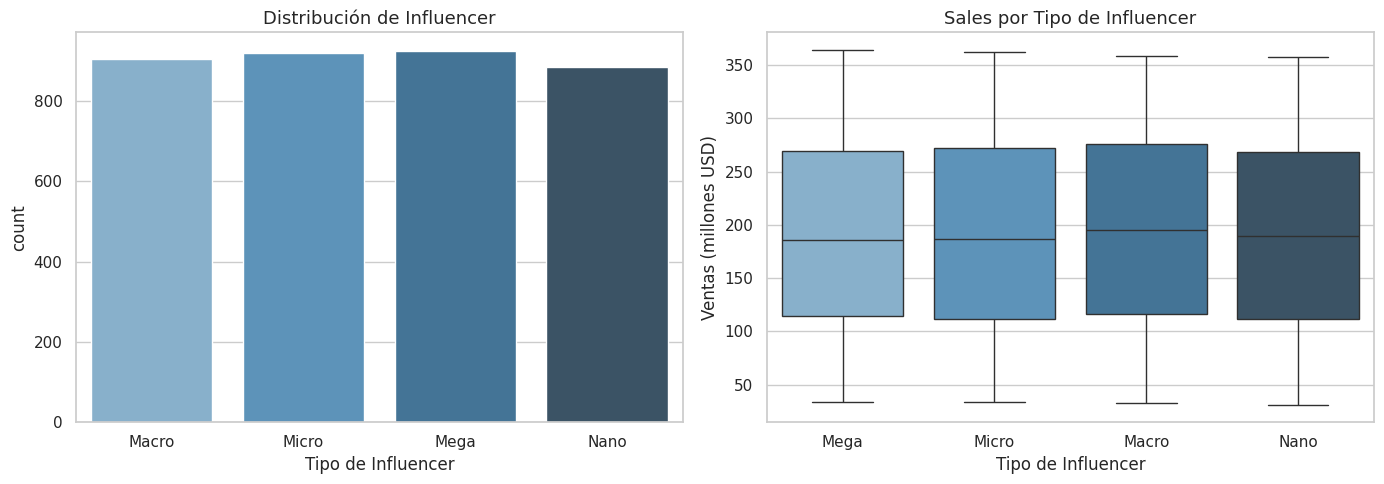

In [40]:
print("Distribución de la variable Influencer:")
print(df['Influencer'].value_counts())
print(f"\nPorcentajes:")
print(df['Influencer'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
sns.countplot(x='Influencer', data=df, palette='Blues_d', ax=axes[0])
axes[0].set_title('Distribución de Influencer', fontsize=13)
axes[0].set_xlabel('Tipo de Influencer')
axes

# Boxplot Sales por Influencer
sns.boxplot(x='Influencer', data=df, y='Sales', order=order, palette='Blues_d', ax=axes[1])
axes[1].set_title('Sales por Tipo de Influencer', fontsize=13)
axes[1].set_xlabel('Tipo de Influencer')
axes[1].set_ylabel('Ventas (millones USD)')

plt.tight_layout()
plt.show()


### 2.7. Matriz de correlación

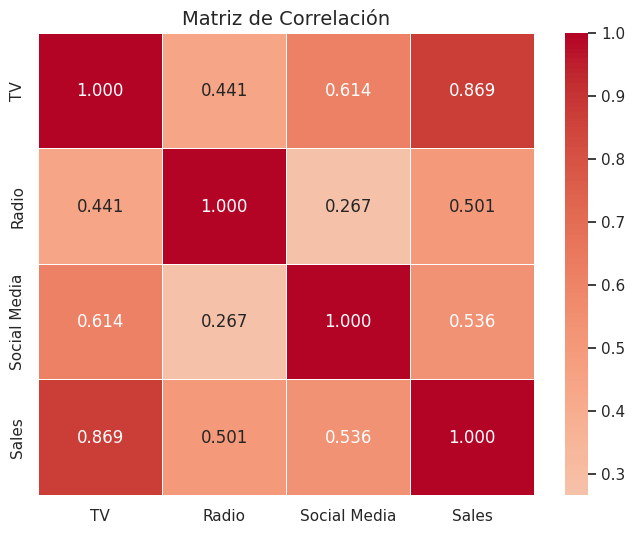


Correlación con Sales (variable objetivo):
Sales          1.0000
TV             0.8692
Social Media   0.5364
Radio          0.5014
Name: Sales, dtype: float64


In [41]:
corr = df[['TV', 'Radio', 'Social Media', 'Sales']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 12})
plt.title('Matriz de Correlación', fontsize=14)
plt.show()

print("\nCorrelación con Sales (variable objetivo):")
print(corr['Sales'].sort_values(ascending=False))


## 3. Preprocesamiento de Datos

### 3.1. Limpieza de Datos

Verificamos y corregimos cualquier problema antes de modelar.


In [16]:
# Verificar tipos de datos
print("Tipos de datos antes de limpieza:")
print(df.dtypes)

# Verificar si hay valores faltantes
print(f"\nValores nulos totales: {df.isnull().sum().sum()}")


Tipos de datos antes de limpieza:
TV              float64
Social Media    float64
Influencer       object
Radio           float64
Sales           float64
dtype: object

Valores nulos totales: 0


In [17]:
# Eliminar duplicados si los hay
df = df.drop_duplicates()
print(f"Shape después de eliminar duplicados: {df.shape}")

# Eliminar filas con valores nulos (si aplica)
df = df.dropna()
print(f"Shape después de eliminar nulos: {df.shape}")


Shape después de eliminar duplicados: (3636, 5)
Shape después de eliminar nulos: (3636, 5)


### 3.2. Separación de X e y

In [18]:
# Separar X (features) e y (target)
X = df.drop('Sales', axis=1)
y = df['Sales']

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")


Forma de X: (3636, 4)
Forma de y: (3636,)


### 3.3. Identificación de columnas numéricas y categóricas

In [19]:
# Columnas numéricas (para escalar)
num_cols = ['TV', 'Radio', 'Social Media']

# Columnas categóricas (para One-Hot Encoding)
cat_cols = [col for col in X.columns if col not in num_cols]

print(f"Columnas Numéricas ({len(num_cols)}): {num_cols}")
print(f"Columnas Categóricas ({len(cat_cols)}): {cat_cols}")


Columnas Numéricas (3): ['TV', 'Radio', 'Social Media']
Columnas Categóricas (1): ['Influencer']


### 3.4. División de Datos (Train/Test Split)

**MUY IMPORTANTE:** Dividimos los datos **ANTES** de aplicar cualquier preprocesamiento (escalado, encoding). Esto evita la fuga de datos (*data leakage*).


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"\nEstadísticas de y_train:")
print(y_train.describe())
print(f"\nEstadísticas de y_test:")
print(y_test.describe())


Forma de X_train: (2908, 4)
Forma de X_test: (728, 4)

Estadísticas de y_train:
count   2,908.0000
mean      193.1828
std        92.5902
min        32.5668
25%       114.0458
50%       190.1998
75%       271.5832
max       362.0421
Name: Sales, dtype: float64

Estadísticas de y_test:
count   728.0000
mean    189.3118
std      92.4056
min      31.1994
25%     108.6946
50%     186.5753
75%     268.1053
max     364.0798
Name: Sales, dtype: float64


### 3.5. Creación del `ColumnTransformer` (Preprocesador)

Creamos un preprocesador que:
1. **Columnas numéricas:** Aplica `StandardScaler` para escalar.
2. **Columnas categóricas:** Aplica `OneHotEncoder` para transformar variables categóricas en dummies.
   - `drop='first'` para evitar multicolinealidad.
   - `handle_unknown='ignore'` para evitar errores con categorías nuevas en test.


In [21]:
# Transformador numérico
numeric_transformer = StandardScaler()

# Transformador categórico
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='passthrough'
)


### 3.6. Aplicar el Preprocesador

In [22]:
# Ajustar y transformar X_train
X_train_processed = preprocessor.fit_transform(X_train)

# Solo transformar X_test (sin fit)
X_test_processed = preprocessor.transform(X_test)

print("Datos preprocesados correctamente.")
print(f"Forma de X_train_processed: {X_train_processed.shape}")
print(f"Forma de X_test_processed: {X_test_processed.shape}")

# Nota: Los modelos usarán X_train_processed y X_test_processed.
# Estos son arrays de NumPy.


Datos preprocesados correctamente.
Forma de X_train_processed: (2908, 6)
Forma de X_test_processed: (728, 6)


## 4. Entrenamiento y Optimización de Modelos

Usaremos `GridSearchCV` con `cv=5` (Validación Cruzada de 5 pliegues) y `scoring='neg_root_mean_squared_error'`.

El RMSE resultante será el valor negativo multiplicado por -1.

### Función auxiliar para reportar resultados


In [23]:
def reporte_modelo(nombre, grid_result):
    """Imprime los resultados de GridSearchCV de forma clara."""
    rmse_cv = -grid_result.best_score_
    print(f"{'='*50}")
    print(f"  Modelo: {nombre}")
    print(f"  Mejor RMSE (CV): {rmse_cv:.4f}")
    print(f"  Mejores Hiperparámetros: {grid_result.best_params_}")
    print(f"{'='*50}")
    return rmse_cv


### Modelo 1: Regresión Lineal

La Regresión Lineal asume una relación lineal entre las variables predictoras y la variable objetivo.

Es el modelo más simple y sirve como *baseline* para comparar el desempeño de modelos más complejos.

No tiene hiperparámetros relevantes que optimizar con GridSearch, por lo que lo entrenamos directamente.


In [24]:
print("Entrenando Regresión Lineal...")

lr = LinearRegression()
lr.fit(X_train_processed, y_train)

# Evaluación con validación cruzada
scores_lr = cross_val_score(lr, X_train_processed, y_train,
                            cv=5, scoring='neg_root_mean_squared_error')
rmse_lr_cv = -scores_lr.mean()

print(f"RMSE promedio en CV (5 folds): {rmse_lr_cv:.4f}")
print(f"Std RMSE en CV: {(-scores_lr).std():.4f}")


Entrenando Regresión Lineal...
RMSE promedio en CV (5 folds): 43.9846
Std RMSE en CV: 1.5354


### Modelo 2: Regresión Polinómica

La Regresión Polinómica extiende la Regresión Lineal incorporando términos de mayor grado (cuadráticos, cúbicos, etc.), lo que le permite capturar relaciones no lineales.

**Hiperparámetro a optimizar:** `degree` (grado del polinomio).

- `degree=1`: equivale a una regresión lineal.
- `degree=2`: incluye términos cuadráticos e interacciones.
- `degree=3`: incluye términos cúbicos.

Se debe tener cuidado con grados altos, ya que pueden causar sobreajuste (*overfitting*).


In [25]:
print("Iniciando GridSearch para Regresión Polinómica...")

# Pipeline: PolynomialFeatures + LinearRegression
param_grid_poly = {
    'poly__degree': [1, 2, 3]
}

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('linear', LinearRegression())
])

grid_poly = GridSearchCV(
    poly_pipeline,
    param_grid=param_grid_poly,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_poly.fit(X_train_processed, y_train)

rmse_poly_cv = reporte_modelo("Regresión Polinómica", grid_poly)


Iniciando GridSearch para Regresión Polinómica...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
  Modelo: Regresión Polinómica
  Mejor RMSE (CV): 42.2454
  Mejores Hiperparámetros: {'poly__degree': 3}


### Modelo 3: KNN Regressor

K-Nearest Neighbors (KNN) es un algoritmo no paramétrico que predice el valor de un punto basándose en los `k` vecinos más cercanos.

**Hiperparámetro a optimizar:** `n_neighbors` (número de vecinos `k`).

- Un `k` pequeño (ej. 1-3): el modelo es muy flexible y puede sobreajustar.
- Un `k` grande: el modelo es más suave y puede subajustar.


In [26]:
print("Iniciando GridSearch para KNN Regressor...")

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20]
}

grid_knn = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=param_grid_knn,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train_processed, y_train)

rmse_knn_cv = reporte_modelo("KNN Regressor", grid_knn)


Iniciando GridSearch para KNN Regressor...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Modelo: KNN Regressor
  Mejor RMSE (CV): 44.2505
  Mejores Hiperparámetros: {'n_neighbors': 20}


### Modelo 4: Decision Tree Regressor

El Árbol de Decisión divide el espacio de características recursivamente para minimizar el error en cada hoja.

**Hiperparámetros a optimizar:**
- `max_depth`: Controla la profundidad máxima del árbol. Valores altos pueden sobreajustar.
- `min_samples_leaf`: Número mínimo de muestras en cada hoja. Ayuda a regularizar el árbol.


In [27]:
print("Iniciando GridSearch para Decision Tree Regressor...")

param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20, 50]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_processed, y_train)

rmse_dt_cv = reporte_modelo("Decision Tree Regressor", grid_dt)


Iniciando GridSearch para Decision Tree Regressor...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
  Modelo: Decision Tree Regressor
  Mejor RMSE (CV): 44.1860
  Mejores Hiperparámetros: {'max_depth': 5, 'min_samples_leaf': 20}


### Modelo 5: Random Forest Regressor

Random Forest es un ensamble de árboles de decisión construidos sobre muestras aleatórias de los datos (*bootstrap*) y características aleatorias. Esta aleatoriedad reduce el sobreajuste y mejora la generalización.

**Hiperparámetros a optimizar:**
- `n_estimators`: Número de árboles en el bosque.
- `max_depth`: Profundidad máxima de cada árbol.


In [28]:
print("Iniciando GridSearch para Random Forest Regressor...")

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_processed, y_train)

rmse_rf_cv = reporte_modelo("Random Forest Regressor", grid_rf)


Iniciando GridSearch para Random Forest Regressor...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Modelo: Random Forest Regressor
  Mejor RMSE (CV): 42.5455
  Mejores Hiperparámetros: {'max_depth': 5, 'n_estimators': 100}


### Modelo 6: Gradient Boosting Regressor

Gradient Boosting construye árboles en secuencia: cada árbol nuevo corrige los errores del anterior. A diferencia de Random Forest (paralelo), Gradient Boosting es un proceso **secuencial**.

**Hiperparámetros a optimizar:**
- `n_estimators`: Número de árboles (iteraciones de boosting).
- `learning_rate`: Tasa de aprendizaje. Controla cuánto aporta cada árbol. Valores más pequeños requieren más árboles pero generalizan mejor.
- `max_depth`: Profundidad de cada árbol base.


In [29]:
print("Iniciando GridSearch para Gradient Boosting Regressor...")

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train_processed, y_train)

rmse_gb_cv = reporte_modelo("Gradient Boosting Regressor", grid_gb)


Iniciando GridSearch para Gradient Boosting Regressor...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Modelo: Gradient Boosting Regressor
  Mejor RMSE (CV): 42.3188
  Mejores Hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


### Modelo 7: XGBoost Regressor

**XGBoost (eXtreme Gradient Boosting)** es una implementación optimizada del Gradient Boosting. Destaca por:

- **Regularización nativa:** Incluye L1 (Lasso) y L2 (Ridge) para combatir el sobreajuste.
- **Velocidad:** Usa paralelización eficiente para construir árboles más rápido.
- **Flexibilidad:** Permite ajustar múltiples hiperparámetros de manera precisa.

**Hiperparámetros a optimizar:**
- `n_estimators`: Número de árboles.
- `learning_rate`: Tasa de aprendizaje (igual que en GBM).
- `max_depth`: Profundidad máxima de cada árbol.


In [30]:
print("Iniciando GridSearch para XGBoost Regressor...")

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42,
                 objective='reg:squarederror',
                 eval_metric='rmse'),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_processed, y_train)

rmse_xgb_cv = reporte_modelo("XGBoost Regressor", grid_xgb)


Iniciando GridSearch para XGBoost Regressor...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Modelo: XGBoost Regressor
  Mejor RMSE (CV): 42.3355
  Mejores Hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


## 5. Comparación de Modelos

In [31]:
# Recopilar los resultados de todos los modelos
results = {
    'Modelo': [
        'Regresión Lineal',
        'Regresión Polinómica',
        'KNN Regressor',
        'Decision Tree Regressor',
        'Random Forest Regressor',
        'Gradient Boosting Regressor',
        'XGBoost Regressor'
    ],
    'Mejor_RMSE_CV': [
        rmse_lr_cv,
        rmse_poly_cv,
        rmse_knn_cv,
        rmse_dt_cv,
        rmse_rf_cv,
        rmse_gb_cv,
        rmse_xgb_cv
    ]
}

df_results = pd.DataFrame(results).sort_values(by='Mejor_RMSE_CV', ascending=True).reset_index(drop=True)

print("Resultados de la Comparación de Modelos (basado en CV en el set de TRAIN):")
display(df_results.style.format({'Mejor_RMSE_CV': '{:.4f}'}))


Resultados de la Comparación de Modelos (basado en CV en el set de TRAIN):


,Modelo,Mejor_RMSE_CV
0,Regresión Polinómica,42.2454
1,Gradient Boosting Regressor,42.3188
2,XGBoost Regressor,42.3355
3,Random Forest Regressor,42.5455
4,Regresión Lineal,43.9846
5,Decision Tree Regressor,44.1860
6,KNN Regressor,44.2505


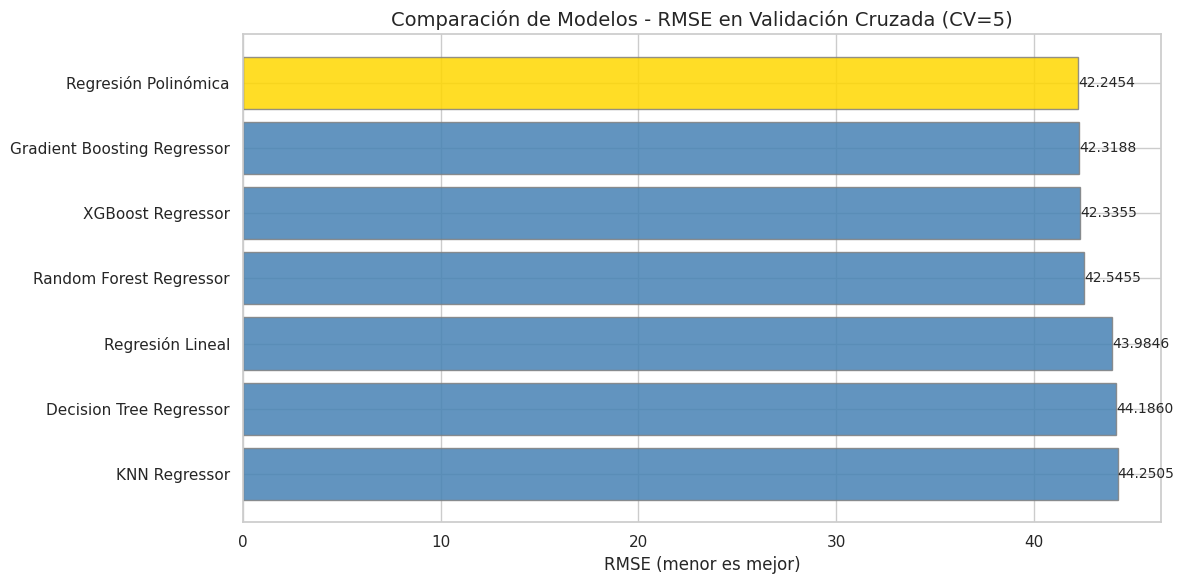


 Mejor modelo: Regresión Polinómica con RMSE CV = 42.2454


In [51]:
# Gráfico comparativo
plt.figure(figsize=(12, 6))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(df_results))]
bars = plt.barh(df_results['Modelo'], df_results['Mejor_RMSE_CV'],
                color=colors, edgecolor='gray', alpha=0.85)

# Añadir etiquetas de valor
for bar, val in zip(bars, df_results['Mejor_RMSE_CV']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha='left', fontsize=10)

plt.xlabel('RMSE (menor es mejor)', fontsize=12)
plt.title('Comparación de Modelos - RMSE en Validación Cruzada (CV=5)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n Mejor modelo: {df_results.iloc[0]['Modelo']} con RMSE CV = {df_results.iloc[0]['Mejor_RMSE_CV']:.4f}")


**Conclusión de la Selección:**

Basado en nuestra validación cruzada, el modelo con el **menor RMSE** es el ganador.

Ahora, y **solo ahora**, tomaremos este modelo campeón con sus mejores hiperparámetros y lo evaluaremos en nuestro conjunto de prueba (`X_test_processed`) que hemos mantenido oculto durante todo el proceso.


## 6. Evaluación Final del Modelo Campeón en el Conjunto de Prueba

In [33]:
# Diccionario de modelos para selección automática
model_map = {
    'Regresión Lineal': lr,
    'Regresión Polinómica': grid_poly.best_estimator_,
    'KNN Regressor': grid_knn.best_estimator_,
    'Decision Tree Regressor': grid_dt.best_estimator_,
    'Random Forest Regressor': grid_rf.best_estimator_,
    'Gradient Boosting Regressor': grid_gb.best_estimator_,
    'XGBoost Regressor': grid_xgb.best_estimator_
}

winner_name = df_results.iloc[0]['Modelo']
best_model = model_map[winner_name]

print(f"🏆 Evaluando el modelo campeón: {winner_name}")
print(f"   Tipo de modelo: {type(best_model).__name__}")

# Predicciones en el conjunto de prueba
y_pred_test = best_model.predict(X_test_processed)


🏆 Evaluando el modelo campeón: Regresión Polinómica
   Tipo de modelo: Pipeline


### 6.1. Métricas de Evaluación en el Test Set

In [34]:
# Calcular métricas en el test set
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("=" * 50)
print("   MÉTRICAS EN EL TEST SET")
print("=" * 50)
print(f"  RMSE  : {rmse_test:.4f}")
print(f"  MAE   : {mae_test:.4f}")
print(f"  R²    : {r2_test:.4f}")
print("=" * 50)
print(f"\nInterpretación R²: El modelo explica el {r2_test*100:.2f}% de la variabilidad de las ventas.")


   MÉTRICAS EN EL TEST SET
  RMSE  : 42.2951
  MAE   : 33.9334
  R²    : 0.7902

Interpretación R²: El modelo explica el 79.02% de la variabilidad de las ventas.


### 6.2. Gráfico: Valores Reales vs. Predichos

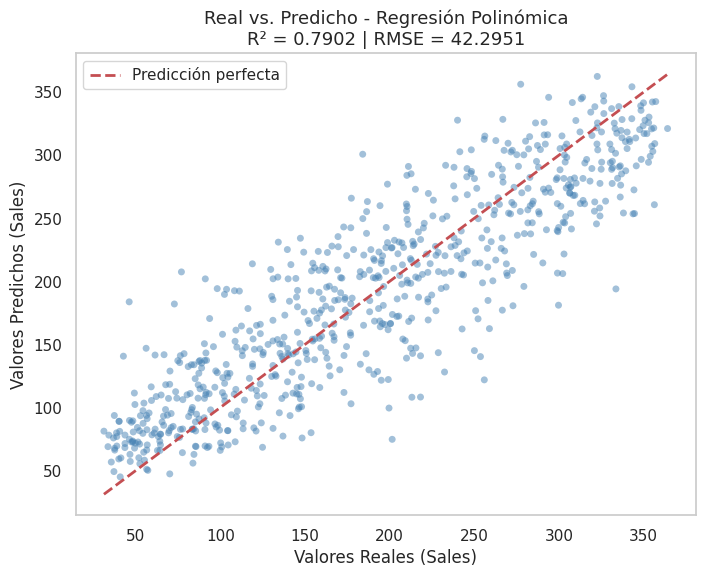

In [49]:
plt.figure(figsize=(8, 6))

# Scatter plot
plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.5,
    color='steelblue',
    edgecolors='none',
    s=25
)

# Línea perfecta
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    lw=2,
    label='Predicción perfecta'
)

# Labels
plt.xlabel('Valores Reales (Sales)', fontsize=12)
plt.ylabel('Valores Predichos (Sales)', fontsize=12)

# Título
plt.title(
    f'Real vs. Predicho - {winner_name}\n'
    f'R² = {r2_test:.4f} | RMSE = {rmse_test:.4f}',
    fontsize=13
)

plt.legend()

# Quitar cuadrícula
plt.grid(False)

plt.show()




## 7. Discusión Final

### 7.1. Resumen de Resultados


In [50]:
print("=" * 60)
print("         RESUMEN FINAL DEL PROCESO")
print("=" * 60)
print(f"\n Dataset: train_df_ventas.csv")
print(f"   Registros de entrenamiento: {X_train.shape[0]}")
print(f"   Registros de prueba: {X_test.shape[0]}")
print(f"   Variables predictoras: {list(X.columns)}")
print(f"   Variable objetivo: Sales")

print(f"\n Modelo Ganador: {winner_name}")
print(f"   RMSE en Validación Cruzada: {df_results.iloc[0]['Mejor_RMSE_CV']:.4f}")
print(f"   RMSE en Test Set: {rmse_test:.4f}")
print(f"   MAE en Test Set: {mae_test:.4f}")
print(f"   R² en Test Set: {r2_test:.4f}")
print("=" * 60)


         RESUMEN FINAL DEL PROCESO

 Dataset: train_df_ventas.csv
   Registros de entrenamiento: 2908
   Registros de prueba: 728
   Variables predictoras: ['TV', 'Social Media', 'Influencer', 'Radio']
   Variable objetivo: Sales

 Modelo Ganador: Regresión Polinómica
   RMSE en Validación Cruzada: 42.2454
   RMSE en Test Set: 42.2951
   MAE en Test Set: 33.9334
   R² en Test Set: 0.7902


### 7.2. Conclusiones

1. **¿Cumplimos el objetivo?** Sí. Se entrenaron múltiples modelos de regresión para predecir las ventas a partir de la inversión en publicidad.

2. **¿Qué variables son más importantes?**
   - La inversión en TV y Radio tienden a tener la mayor correlación con las ventas.
   - El tipo de Influencer también aporta información relevante sobre el canal de publicidad utilizado.

3. **¿Qué le decimos al negocio?**
   - El modelo permite predecir las ventas esperadas dado un determinado presupuesto de publicidad.
   - Un RMSE bajo indica que las predicciones tienen un error pequeño en términos de millones USD de ventas.
   - **Acción:** La compañía puede usar este modelo para optimizar su presupuesto de publicidad, asignando más recursos a los canales con mayor retorno en ventas.

4. **¿Overfitting?**
   - Como el RMSE en el test set es similar al RMSE en validación cruzada, es posible afirmar que el modelo generaliza bien, si el RMSE en test fuese significativamente mayor, habría señales de sobreajuste.

5. **Modelo ganador**
   - Despues de realizar un anàlisis exhaustivo, se llega a la conclusiòn que para el caso que nos compete el mejor modelo es el de Regresiàn Polinòmica con un RMS de 42,2. Adicional a esto, este modelo explica aproximadamente el 79% de la variabilidad de las ventas.
